# **Análise de Preços de Casas**

### **Importando Libs**

In [2]:
# Importando as bíbliotecas que serão úteis para a presente análise
import pandas as pd                 # Manipulaçãp de tabelas
import seaborn as sns               # Manipulação de gráficos
import numpy as np                  # Operações matemáticas
import matplotlib.pyplot as plt     # Manipulação de gráficos

### **Dataset**

In [3]:
df = pd.read_csv('../../data/datasets_profa_renata_biaggi/house_price.csv')

In [4]:
df

,Unnamed: 0,SalePrice,OverallQual,OverallCond,BedroomAbvGr,TotRmsAbvGrd,GrLivArea,TotalBsmtSF,YearBuilt,MSZoning,Utilities,BldgType
0,0,208500,7,5,3,8,1710,856,2003,RL,AllPub,1Fam
1,1,181500,6,8,3,6,1262,1262,1976,RL,AllPub,1Fam
2,2,223500,7,5,3,6,1786,920,2001,RL,AllPub,1Fam
3,3,140000,7,5,3,7,1717,756,1915,RL,AllPub,1Fam
4,4,250000,8,5,4,9,2198,1145,2000,RL,AllPub,1Fam
...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1455,175000,6,5,3,7,1647,953,1999,RL,AllPub,1Fam
1456,1456,210000,6,6,3,7,2073,1542,1978,RL,AllPub,1Fam
1457,1457,266500,7,9,4,9,2340,1152,1941,RL,AllPub,1Fam
1458,1458,142125,5,6,2,5,1078,1078,1950,RL,AllPub,1Fam


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Unnamed: 0    1460 non-null   int64
 1   SalePrice     1460 non-null   int64
 2   OverallQual   1460 non-null   int64
 3   OverallCond   1460 non-null   int64
 4   BedroomAbvGr  1460 non-null   int64
 5   TotRmsAbvGrd  1460 non-null   int64
 6   GrLivArea     1460 non-null   int64
 7   TotalBsmtSF   1460 non-null   int64
 8   YearBuilt     1460 non-null   int64
 9   MSZoning      1460 non-null   str  
 10  Utilities     1460 non-null   str  
 11  BldgType      1460 non-null   str  
dtypes: int64(9), str(3)
memory usage: 154.6 KB



```
- SalePrice: Preço de venda
- OverallQual: Avalia a qualidade geral dos materiais e do acabamento da casa
- OverallCond: Avalia a condição geral da casa
- BedroomAbvGr: Quartos acima do nível do solo (NÃO inclui quartos no porão)
- TotRmsAbvGrd: Total de cômodos acima do nível do solo (não inclui banheiros)
- GrLivArea: Área habitável acima do nível do solo (térreo) em pés quadrados
- TotalBsmtSF: Área total do porão em pés quadrados

- YearBuilt: Data original da construção

- MSZoning - Identifica a classificação geral de zoneamento da venda
       A	Agrícola
       C	Comercial
       FV	Residencial de Vila Flutuante
       I	Industrial
       RH	Residencial de Alta Densidade
       RL	Residencial de Baixa Densidade
       RP	Residencial de Baixa Densidade com Parque
       RM	Residencial de Média Densidade

- Utilities: Tipo de utilidades disponíveis
       AllPub	Todas as utilidades públicas (Eletricidade, Gás, Água e Esgoto)
       NoSewr	Eletricidade, Gás e Água (Fossa séptica)
       NoSeWa	Apenas Eletricidade e Gás
       ELO	   Apenas Eletricidade

- BldgType: Tipo de edificação
       1Fam	   Residência unifamiliar isolada
       2FmCon	Conversão para duas famílias; originalmente construída como residência unifamiliar
       Duplx	   Duplex
       TwnhsE	Sobrado de ponta (unidade final)
       TwnhsI	Sobrado de meio (unidade interna)
```

**Primeiro questionamento:** Será que existem células vazias nessas colunas? Quantas?

Essa é uma pergunta que sempre fazemos ao analisar um dataset. O código abaixo serve para isso.

In [6]:
df.isnull().sum()
#NaN, #null, #missing ----> 

Unnamed: 0      0
SalePrice       0
OverallQual     0
OverallCond     0
BedroomAbvGr    0
TotRmsAbvGrd    0
GrLivArea       0
TotalBsmtSF     0
YearBuilt       0
MSZoning        0
Utilities       0
BldgType        0
dtype: int64

#### **Medidas de Tendência Central**

In [7]:
# Medidas de Tendência Central
mean = df['SalePrice'].mean()       # Média
median = df['SalePrice'].median()   # Mediana
mode = df['SalePrice'].mode()       # Moda

print(f'Média: {mean:,.2f}')
print(f'Mediana: {median:,.2f}')
print(f'Moda: {mode}')

Média: 180,921.20
Mediana: 163,000.00
Moda: 0    140000
Name: SalePrice, dtype: int64


In [8]:
df.SalePrice.describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: ylabel='SalePrice'>

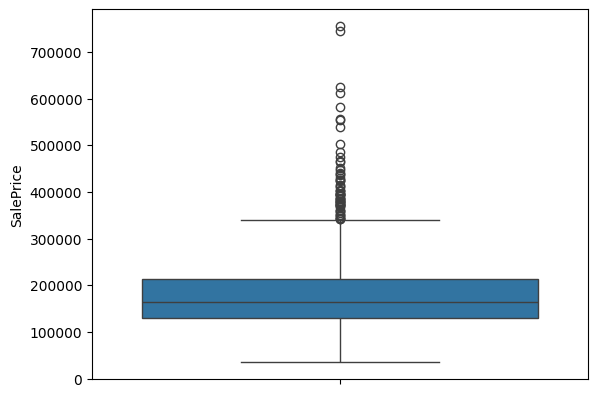

In [9]:
# Boxplot
sns.boxplot(df.SalePrice)
# df.SalePrice é igual a df['SalePrice']

Constatamos que a média de preço está em torno de 180.9K, porém a mediana cai para em torno de 163K. O fato de termos a mediana deslocada da média com um valor nos diz que temos poucas casas com um valor muito alto – elevando a média e divegindo bastante do valor do restante das casas.

### **Hipóteses**

Das variáveis **numéricas**, podemos pensar em três hipóteses:

1.   A média/mediana da qualidade do imóvel é superior para os apartamentos mais caros
2.   A média/mediana da quantidade de cômodos/quartos/área/banheiros é maior em apartamentos mais caros
3.   Os apartamentos mais caros são mais antigos

Das variáveis **categóricas**, podemos pensar em três hipóteses:

1.   Existe diferença de preço de acordo com sua localização (zona)
2.   As utilidades (gás, água, etc) existentes na casa tem influência no preço
3.   O tipo de habitação influencia o preço (duplex, condomínio, etc)

Agora, precisamos validar se essas hipóteses são verdadeiras ou não com dados


#### **Numéricas**

In [10]:
df.describe()

,Unnamed: 0,SalePrice,OverallQual,OverallCond,BedroomAbvGr,TotRmsAbvGrd,GrLivArea,TotalBsmtSF,YearBuilt
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,729.500000,180921.195890,6.099315,5.575342,2.866438,6.517808,1515.463699,1057.429452,1971.267808
std,421.610009,79442.502883,1.382997,1.112799,0.815778,1.625393,525.480383,438.705324,30.202904
min,0.000000,34900.000000,1.000000,1.000000,0.000000,2.000000,334.000000,0.000000,1872.000000
25%,364.750000,129975.000000,5.000000,5.000000,2.000000,5.000000,1129.500000,795.750000,1954.000000
50%,729.500000,163000.000000,6.000000,5.000000,3.000000,6.000000,1464.000000,991.500000,1973.000000
75%,1094.250000,214000.000000,7.000000,6.000000,3.000000,7.000000,1776.750000,1298.250000,2000.000000
max,1459.000000,755000.000000,10.000000,9.000000,8.000000,14.000000,5642.000000,6110.000000,2010.000000


Para varlidarmos as hipóteses, vamos criar uma coluna que nos diga se a casa era "cara" ou se a casa era "barata – sendo que o que definirmos como "cara" são as casas acima do percentil 75 (214K) e como "baratas" as casas abaixo desse percentil 75.

In [14]:
# Para criação de colunas, precisa ter a sintaxe df['NomeDaColunaNova'], não pode ser apenas df.NomeDaColunaNova
df['CategoriaPreco'] = np.where(df['SalePrice'] > 214000, "cara", "barata")
df

,Unnamed: 0,SalePrice,OverallQual,OverallCond,BedroomAbvGr,TotRmsAbvGrd,GrLivArea,TotalBsmtSF,YearBuilt,MSZoning,Utilities,BldgType,CategoriaPreco
0,0,208500,7,5,3,8,1710,856,2003,RL,AllPub,1Fam,barata
1,1,181500,6,8,3,6,1262,1262,1976,RL,AllPub,1Fam,barata
2,2,223500,7,5,3,6,1786,920,2001,RL,AllPub,1Fam,cara
3,3,140000,7,5,3,7,1717,756,1915,RL,AllPub,1Fam,barata
4,4,250000,8,5,4,9,2198,1145,2000,RL,AllPub,1Fam,cara
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1455,175000,6,5,3,7,1647,953,1999,RL,AllPub,1Fam,barata
1456,1456,210000,6,6,3,7,2073,1542,1978,RL,AllPub,1Fam,barata
1457,1457,266500,7,9,4,9,2340,1152,1941,RL,AllPub,1Fam,cara
1458,1458,142125,5,6,2,5,1078,1078,1950,RL,AllPub,1Fam,barata


Calculando as estatísticas de cada uma das categorias criadas

Média:  CategoriaPreco
barata    5.588342
cara      7.649171
Name: OverallQual, dtype: float64
Mediana:  CategoriaPreco
barata    6.0
cara      8.0
Name: OverallQual, dtype: float64


([0, 1], [Text(0, 0, 'barata'), Text(1, 0, 'cara')])

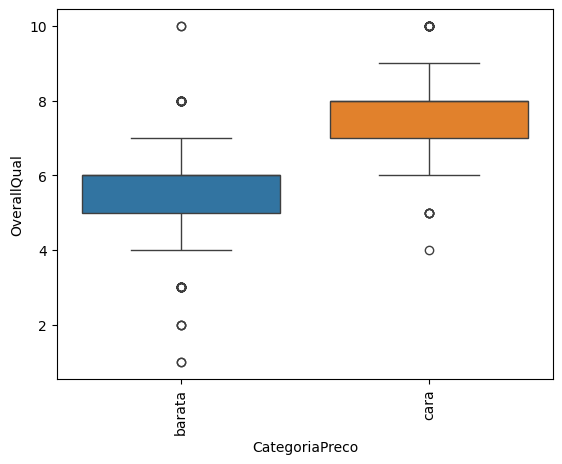

In [18]:
fig = sns.boxplot(x='CategoriaPreco', y="OverallQual", data=df, hue='CategoriaPreco')
print('Média: ', df.groupby('CategoriaPreco')['OverallQual'].mean())
print('Mediana: ', df.groupby('CategoriaPreco')['OverallQual'].median())
plt.xticks(rotation=90)

Média:  CategoriaPreco
barata    5.631148
cara      5.406077
Name: OverallCond, dtype: float64
Mediana:  CategoriaPreco
barata    5.0
cara      5.0
Name: OverallCond, dtype: float64


([0, 1], [Text(0, 0, 'barata'), Text(1, 0, 'cara')])

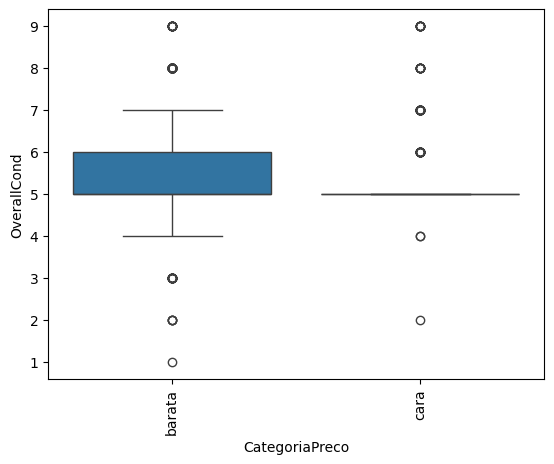

In [19]:
fig = sns.boxplot(x='CategoriaPreco', y="OverallCond", data=df, hue='CategoriaPreco')
print('Média: ', df.groupby('CategoriaPreco')['OverallCond'].mean())
print('Mediana: ', df.groupby('CategoriaPreco')['OverallCond'].median())
plt.xticks(rotation=90)

In [20]:
df[df.CategoriaPreco == 'cara'][['CategoriaPreco', 'OverallCond']]

,CategoriaPreco,OverallCond
2,cara,5
4,cara,5
6,cara,5
11,cara,5
13,cara,5
...,...,...
1437,cara,5
1442,cara,5
1447,cara,5
1451,cara,5


In [21]:
df[df.CategoriaPreco == 'cara'].OverallCond.value_counts()

OverallCond
5    284
7     32
6     25
8      9
9      9
4      2
2      1
Name: count, dtype: int64

Média:  CategoriaPreco
barata    6.122951
cara      7.715470
Name: TotRmsAbvGrd, dtype: float64
Mediana:  CategoriaPreco
barata    6.0
cara      8.0
Name: TotRmsAbvGrd, dtype: float64


([0, 1], [Text(0, 0, 'barata'), Text(1, 0, 'cara')])

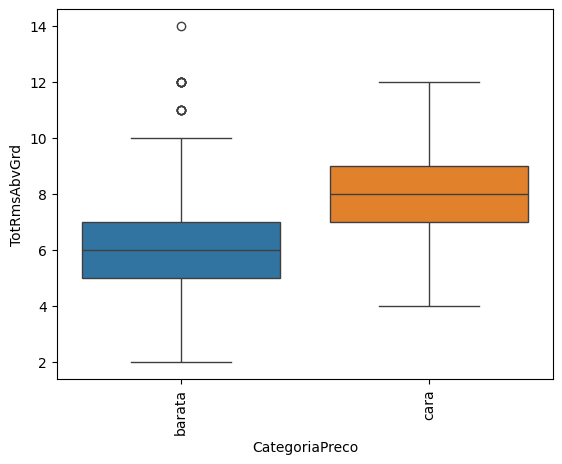

In [22]:
fig = sns.boxplot(x='CategoriaPreco', y="TotRmsAbvGrd", data=df, hue='CategoriaPreco')
print('Média: ', df.groupby('CategoriaPreco')['TotRmsAbvGrd'].mean())
print('Mediana: ', df.groupby('CategoriaPreco')['TotRmsAbvGrd'].median())
plt.xticks(rotation=90)

Média:  CategoriaPreco
barata    1342.642077
cara      2039.657459
Name: GrLivArea, dtype: float64
Mediana:  CategoriaPreco
barata    1308.5
cara      1956.0
Name: GrLivArea, dtype: float64


([0, 1], [Text(0, 0, 'barata'), Text(1, 0, 'cara')])

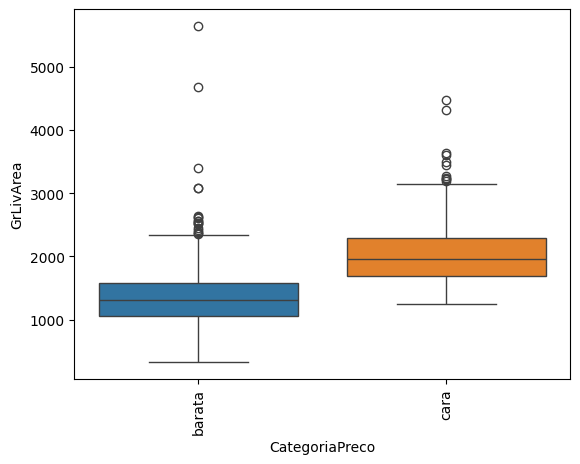

In [23]:
fig = sns.boxplot(x='CategoriaPreco', y="GrLivArea", data=df, hue='CategoriaPreco')
print('Média: ', df.groupby('CategoriaPreco')['GrLivArea'].mean())
print('Mediana: ', df.groupby('CategoriaPreco')['GrLivArea'].median())
plt.xticks(rotation=90)

Média:  CategoriaPreco
barata     936.475410
cara      1424.301105
Name: TotalBsmtSF, dtype: float64
Mediana:  CategoriaPreco
barata     912.0
cara      1452.5
Name: TotalBsmtSF, dtype: float64


([0, 1], [Text(0, 0, 'barata'), Text(1, 0, 'cara')])

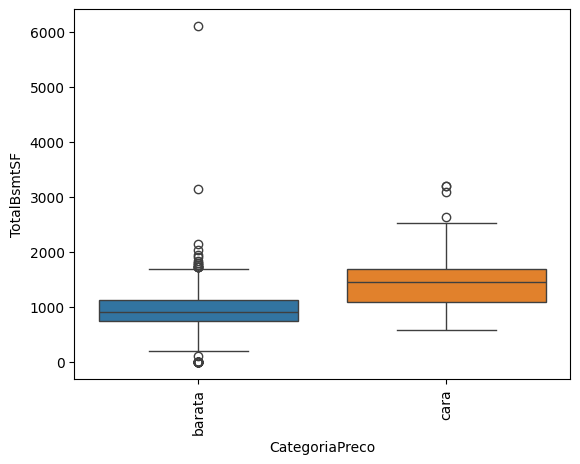

In [24]:
fig = sns.boxplot(x='CategoriaPreco', y="TotalBsmtSF", data=df, hue='CategoriaPreco')
print('Média: ', df.groupby('CategoriaPreco')['TotalBsmtSF'].mean())
print('Mediana: ', df.groupby('CategoriaPreco')['TotalBsmtSF'].median())
plt.xticks(rotation=90)

Média:  CategoriaPreco
barata    1964.303279
cara      1992.392265
Name: YearBuilt, dtype: float64
Mediana:  CategoriaPreco
barata    1965.5
cara      2002.0
Name: YearBuilt, dtype: float64


([0, 1], [Text(0, 0, 'barata'), Text(1, 0, 'cara')])

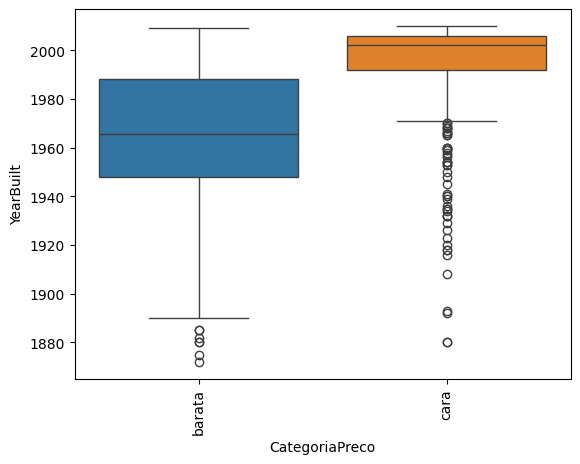

In [25]:
fig = sns.boxplot(x='CategoriaPreco', y="YearBuilt", data=df, hue='CategoriaPreco')
print('Média: ', df.groupby('CategoriaPreco')['YearBuilt'].mean())
print('Mediana: ', df.groupby('CategoriaPreco')['YearBuilt'].median())
plt.xticks(rotation=90)

#### **Correlação**

<Axes: xlabel='SalePrice', ylabel='OverallQual'>

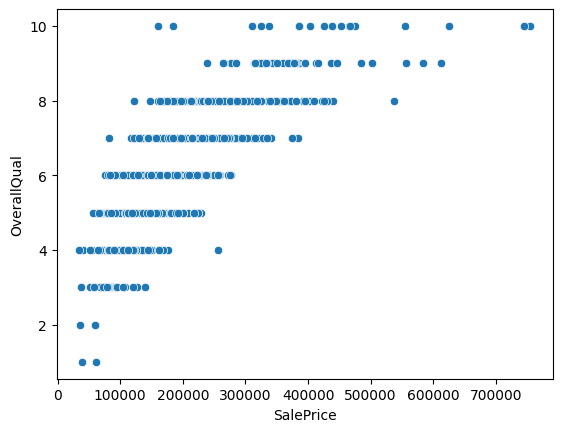

In [26]:
# Qualidade geral: numérico, porém limitado a categorias
sns.scatterplot(x='SalePrice', y='OverallQual', data=df)

<Axes: xlabel='SalePrice', ylabel='GrLivArea'>

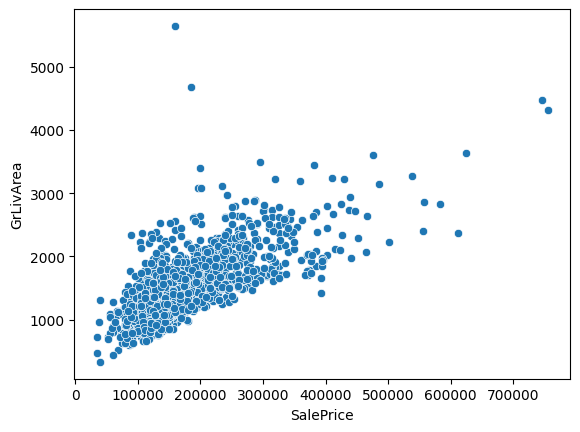

In [27]:
# Área construída
sns.scatterplot(x='SalePrice', y='GrLivArea', data=df)

<Axes: xlabel='SalePrice', ylabel='YearBuilt'>

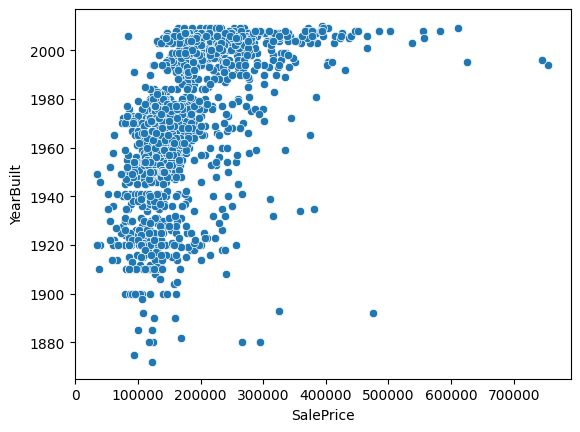

In [28]:
# Ano
sns.scatterplot(x='SalePrice', y='YearBuilt', data=df)

Tanto ano quanto as features de qualidade/quantidade de banheiro, apesar de serem numéricas, pode ser útil entende-las de outra forma. Isso geralmente acontece quando o número é inteiro (não float) e assume uma quantidade limitada e conhecida de "categorias". Chamamos isso de variáveis discretas x contínuas

**Variáveis discretas:** características mensuráveis que podem assumir apenas um número finito ou infinito contável de valores e, assim, somente fazem sentido valores inteiros. Geralmente são o resultado de contagens. Exemplos: número de filhos, número de bactérias por litro de leite, número de cigarros fumados por dia.

**Variáveis contínuas:** características mensuráveis que assumem valores em uma escala contínua (na reta real), para as quais valores fracionais fazem sentido. Usualmente devem ser medidas através de algum instrumento. Exemplos: peso (balança), altura (régua), tempo (relógio), pressão arterial, idade.

**Voltando ao nosso exemplo:**
Uma ideia que pode ser interessante para avaliar variáveis discretas é entender a distribuição de preço em cada um dos valores. Por exemplo, distribuição de preço para qualidade 1, distribuição de preço para qualidade 2, etc. Ou seja, o **X do nosso boxplot será a feature e o Y do boxplot será o preço**

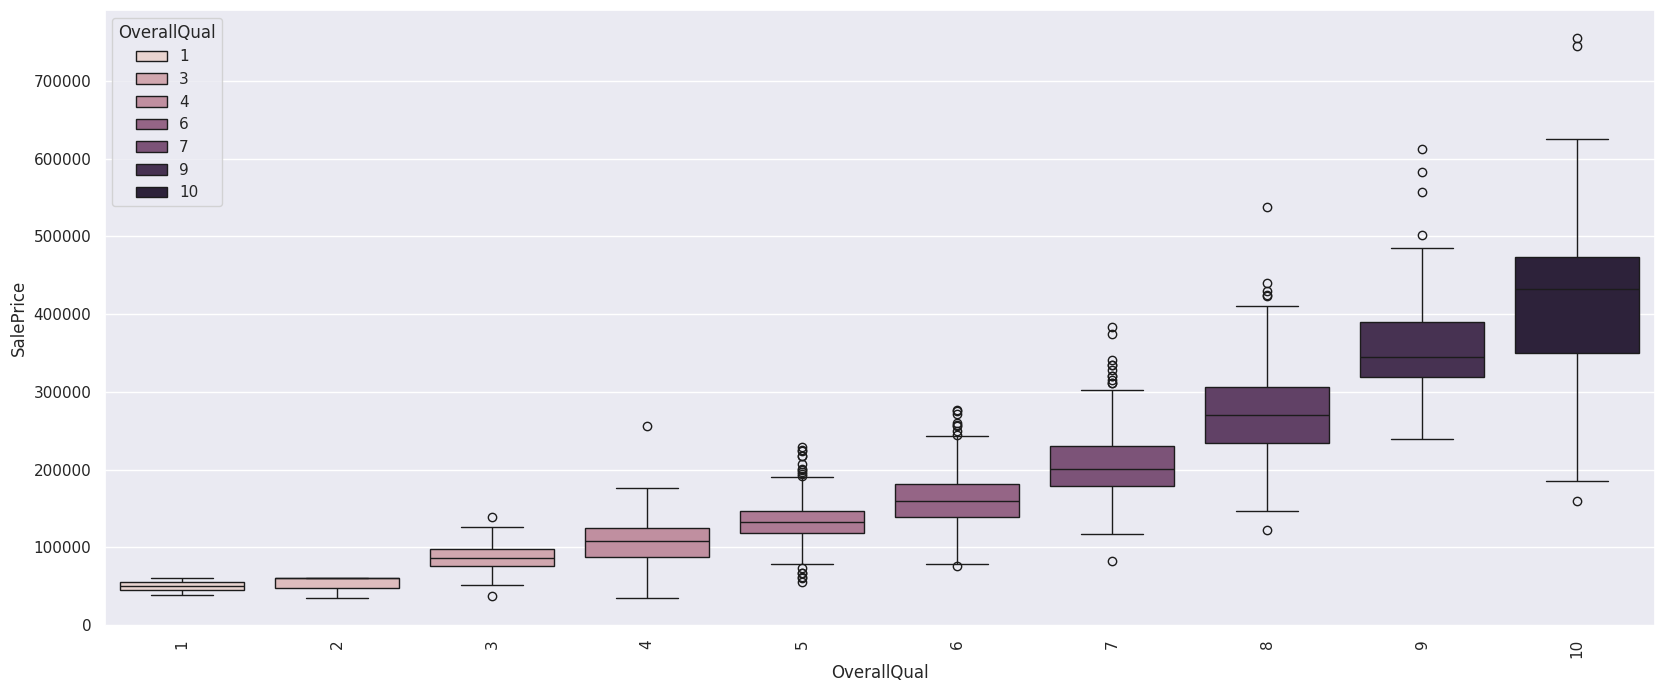

In [31]:
# Qualidade
sns.set(rc = {'figure.figsize':(20,8)})
fig = sns.boxplot(x="OverallQual", y="SalePrice", data=df, hue='OverallQual')
plt.xticks(rotation=90);

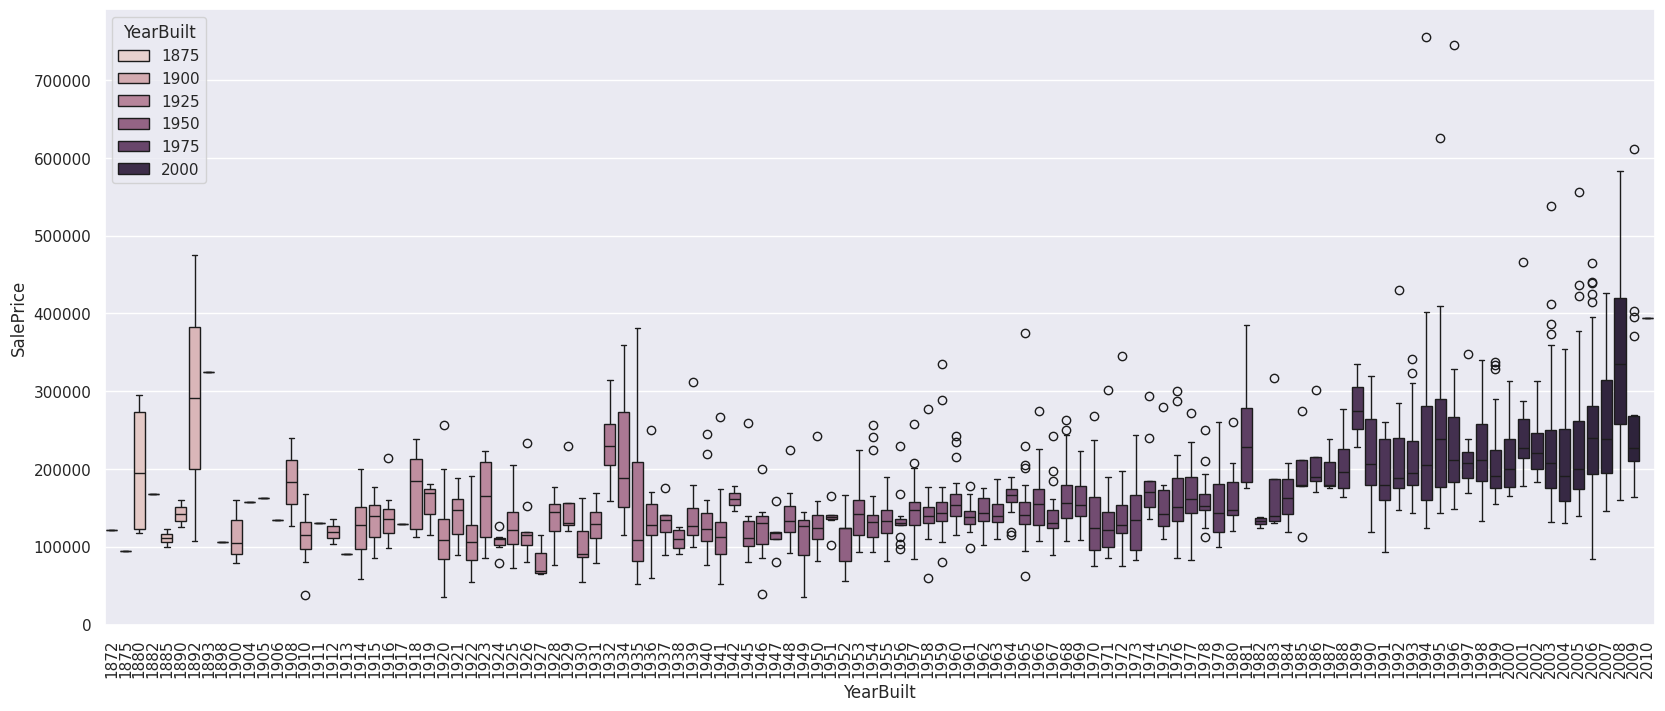

: 

In [ ]:
# Qualidade
sns.set(rc = {'figure.figsize':(20,8)})
fig = sns.boxplot(x="YearBuilt", y="SalePrice", data=df, hue='YearBuilt')
plt.xticks(rotation=90);